In [43]:
# IMPORTANT:
#   Whenever you start a new colab runtime, use the following code to download
#   the training dataset onto the runtime local storage.
#   This should take ~3-5 mins for the whole dataset.
#   You can then load data from the local storage (/content/data) into your colab
#   notebook using the `h5py` library (see example below).
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")

'data/events.csv'

In [44]:
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
import os
import io

In [ ]:
pip install pytorch-lightning

In [ ]:
import pandas as pd

# Load metadata
event_df = pd.read_csv("data/events.csv")

# Convert start_utc to datetime format
event_df["start_utc"] = pd.to_datetime(event_df["start_utc"])

# Filter only vil events
vil_events = event_df[event_df["img_type"] == "vil"]

# Remove timezone (as done in your histogram)
vil_events["start_utc"] = vil_events["start_utc"].dt.tz_localize(None)


In [47]:
time_lower = vil_events["start_utc"].quantile(0.40)
time_upper = vil_events["start_utc"].quantile(0.60)

# Filter dataset based on time range
filtered_events = vil_events[(vil_events["start_utc"] >= time_lower) & (vil_events["start_utc"] <= time_upper)]

# Save filtered metadata
filtered_events.to_csv("filtered_events.csv", index=False)

print(f"Filtered {len(filtered_events)} events based on time distribution.")
print(f"New time range: {time_lower} to {time_upper}")


Filtered 160 events based on time distribution.
New time range: 2019-02-07 11:36:00 to 2019-04-26 19:47:00


In [48]:
import pandas as pd

# Load the filtered event metadata
filtered_events = pd.read_csv("filtered_events.csv")

# Convert `start_utc` to datetime format
filtered_events["start_utc"] = pd.to_datetime(filtered_events["start_utc"])

# Use stricter filtering (25th to 75th percentile)
time_lower = filtered_events["start_utc"].quantile(0.25)
time_upper = filtered_events["start_utc"].quantile(0.75)

# Apply time-based filtering
filtered_events = filtered_events[
    (filtered_events["start_utc"] >= time_lower) & (filtered_events["start_utc"] <= time_upper)
]

# Save the filtered data again
filtered_events.to_csv("filtered_events.csv", index=False)

print(f"✅ After stricter filtering, storms left: {filtered_events['id'].nunique()}")


✅ After stricter filtering, storms left: 80


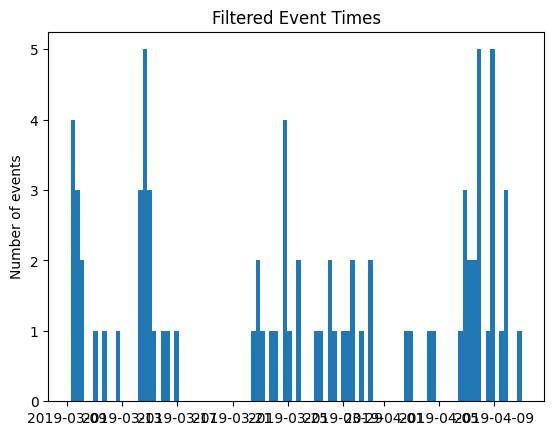

In [49]:
import matplotlib.pyplot as plt

# Plot histogram again after filtering
plt.hist(filtered_events["start_utc"], bins=100)
plt.ylabel("Number of events")
plt.title("Filtered Event Times")
plt.show()


In [50]:
# Load the filtered storm IDs
filtered_events = pd.read_csv("filtered_events.csv")

# Convert to a set for faster lookup
filtered_ids = set(filtered_events["id"].astype(str))  # Ensure they are strings


In [51]:
import h5py
import numpy as np
from tqdm import tqdm

# Reload filtered storm IDs
filtered_events = pd.read_csv("filtered_events.csv")
filtered_ids = set(filtered_events["id"].astype(str))  # Ensure IDs are strings

# Open train.h5
with h5py.File("data/train.h5", "r") as f:
    vis_images, ir069_images, ir107_images, vil_images = [], [], [], []

    # Iterate only through storms in filtered_ids
    for storm_id in tqdm(filtered_ids, desc="Processing filtered storms", unit="storm"):
        if storm_id in f:  # Ensure the storm exists in train.h5
            group = f[storm_id]

            # Extract the correct datasets
            vis_images.append(group["vis"][:])    # Visible
            ir069_images.append(group["ir069"][:])  # Infrared Water Vapor
            ir107_images.append(group["ir107"][:])  # Infrared Cloud Temp
            vil_images.append(group["vil"][:])    # Radar VIL

print(f"✅ Extraction complete! Extracted {len(vis_images)} storms after filtering.")


Processing filtered storms: 100%|██████████| 80/80 [00:12<00:00,  6.34storm/s]

✅ Extraction complete! Extracted 80 storms after filtering.


In [11]:
from tqdm import tqdm  # Import tqdm
import numpy as np
import cv2

# Function to downsample images with tqdm tracking
def downsample(img_array, target_size=(192, 192)):
    return np.array([cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
                     for img in tqdm(img_array, desc="Downsampling", unit="image")])

# Function to normalize images with tqdm tracking (for IR & VIL)
def normalize(img_array):
    return np.array([(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
                     for img in tqdm(img_array, desc="Normalizing", unit="image")])  # Avoid division by zero

# Function to apply contrast stretching for VIS images
def contrast_stretch(img_array):
    stretched_images = []
    for img in tqdm(img_array, desc="Contrast Stretching VIS", unit="image"):
        p2, p98 = np.percentile(img, (2, 98))  # Get percentile limits
        img = (img - p2) / (p98 - p2 + 1e-8)  # Normalize between [0,1]
        img = np.clip(img, 0, 1)  # Clip to [0,1] range
        stretched_images.append(img)
    return np.array(stretched_images)

# 🔹 **Instead of upsampling IR images, we downsample VIS & VIL to match 192x192**
vis_images = downsample(vis_images, target_size=(192, 192))
vil_images = downsample(vil_images, target_size=(192, 192))

# Apply proper processing to each type
vis_images = contrast_stretch(vis_images)  # Apply contrast enhancement for VIS
ir069_images = normalize(ir069_images)  # Normalization for IR images
ir107_images = normalize(ir107_images)
vil_images = normalize(vil_images)  # VIL also normalized

# Save preprocessed data
np.save("preprocessed_vis.npy", vis_images)
np.save("preprocessed_ir069.npy", ir069_images)
np.save("preprocessed_ir107.npy", ir107_images)
np.save("preprocessed_vil.npy", vil_images)

print("\n✅ Preprocessing complete! Data saved.")


Normalizing: 100%|██████████| 80/80 [00:00<00:00, 345.73image/s]



✅ Preprocessing complete! Data saved.


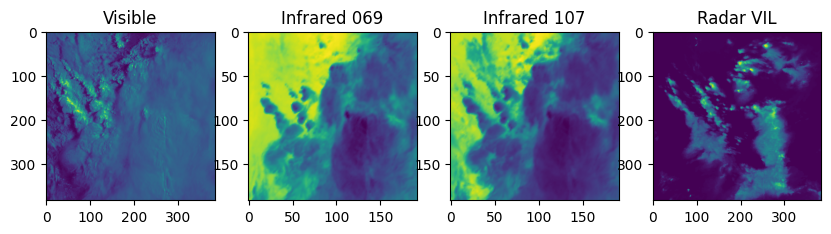

In [52]:
import matplotlib.pyplot as plt

# Select a sample index
idx = 0  # First sample

# Plot sample images
plt.figure(figsize=(10, 5))

plt.subplot(1, 4, 1)
plt.imshow(vis_images[idx][:,:,0])  # Select first channel
plt.title("Visible")

plt.subplot(1, 4, 2)
plt.imshow(ir069_images[idx][:,:,0])  # Select first channel
plt.title("Infrared 069")

plt.subplot(1, 4, 3)
plt.imshow(ir107_images[idx][:,:,0])  # Select first channel
plt.title("Infrared 107")

plt.subplot(1, 4, 4)
plt.imshow(vil_images[idx][:,:,0])  # Select first channel
plt.title("Radar VIL")

plt.show()


In [53]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Custom Dataset with Lazy Loading
class StormDataset(Dataset):
    def __init__(self):
        # Load file paths instead of full numpy arrays (to save RAM)
        self.vis_path = "preprocessed_vis.npy"
        self.ir069_path = "preprocessed_ir069.npy"
        self.ir107_path = "preprocessed_ir107.npy"
        self.vil_path = "preprocessed_vil.npy"

        # Get dataset size (assuming all have the same length)
        with open(self.vis_path, "rb") as f:
            self.dataset_size = np.load(f, allow_pickle=True).shape[0]

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        # Load only one sample at a time (Lazy Loading)
        vis = np.load(self.vis_path, mmap_mode="r")[idx][:,:, :3]  # First 3 channels only
        ir069 = np.load(self.ir069_path, mmap_mode="r")[idx][:,:, :3]
        ir107 = np.load(self.ir107_path, mmap_mode="r")[idx][:,:, :3]
        vil = np.load(self.vil_path, mmap_mode="r")[idx][:,:, 0]  # Only 1 channel

        # Stack inputs (3-channel input)
        X = np.concatenate((vis, ir069, ir107), axis=-1)  # Shape (384, 384, 9)
        X = np.moveaxis(X, -1, 0)  # Convert to (9, 384, 384) for PyTorch

        # Convert to PyTorch Tensors
        X = torch.tensor(X, dtype=torch.float16)  # Use float16 to reduce memory
        y = torch.tensor(vil, dtype=torch.float16)

        return X, y

# Create DataLoader (Batch Size = 4 to Reduce RAM Usage)
batch_size = 4
dataset = StormDataset()
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

# Verify sample shapes
X_sample, y_sample = next(iter(train_loader))
print(f"✅ Data Loaded: Input {X_sample.shape}, Target {y_sample.shape}")


✅ Data Loaded: Input torch.Size([4, 9, 192, 192]), Target torch.Size([4, 192, 192])


In [54]:
import torch.nn as nn
import torch.optim as optim

# Optimized ConvGRU Model (Replaces LSTM with GRU for Lower Memory Usage)
class ConvGRU(nn.Module):
    def __init__(self):
        super(ConvGRU, self).__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv2d(9, 64, kernel_size=3, padding=1)  # (B, 64, 192, 192)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # (B, 128, 192, 192)
        self.bn2 = nn.BatchNorm2d(128)

        # Pooling layer to reduce memory usage further
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)  # (B, 128, 96, 96)

        # **Updated GRU Layer with Correct Input Size**
        self.gru = nn.GRU(128 * 96 * 96, 64, batch_first=True)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64, 96 * 96)  # Match output size
        self.fc2 = nn.Linear(96 * 96, 192 * 192)  # Match final output size

    def forward(self, x):
      # Apply convolutions
      x = torch.relu(self.bn1(self.conv1(x)))
      x = torch.relu(self.bn2(self.conv2(x)))

      # Apply pooling to reduce spatial size
      x = self.pool(x)  # (B, 128, 96, 96) <- Fix

      # Flatten for GRU input
      x = x.view(x.size(0), -1)  # Shape (batch_size, 128*96*96)

      # GRU processing
      x, _ = self.gru(x.unsqueeze(1))  # Add sequence dimension
      x = x[:, -1, :]  # Take last GRU output

      # Fully connected layers
      x = torch.relu(self.fc1(x))
      x = torch.sigmoid(self.fc2(x))  # Final output scaled to [0,1]

      # Reshape output back to image shape
      x = x.view(-1, 192, 192)
      return x


# Initialize model
model = ConvGRU().to("cuda")

# Print model summary
print(model)


ConvGRU(
  (conv1): Conv2d(9, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (gru): GRU(1179648, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=9216, bias=True)
  (fc2): Linear(in_features=9216, out_features=36864, bias=True)
)


In [60]:
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [61]:
from tqdm import tqdm  # Import tqdm
import torch.cuda.amp as amp  # Import for automatic mixed precision

# Ensure model is correctly defined
model = ConvGRU().to("cuda")  # Create a new model instance

# Set CUDA memory optimization
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments=True"

# Define loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Fixed error

# Enable automatic mixed precision (float16)
scaler = torch.amp.GradScaler(device="cuda")

# Compile model for optimized execution (PyTorch 2.0+)
model = torch.compile(model)

# Reduce batch size and increase accumulation steps
batch_size = 2
accumulation_steps = 4

# Training loop with tqdm tracking and memory optimization
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # tqdm progress bar for batch processing
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

    for i, (inputs, targets) in enumerate(progress_bar):
        # Move data to GPU with automatic mixed precision
        inputs, targets = inputs.to("cuda").half(), targets.to("cuda").half()

        with torch.amp.autocast(device_type="cuda"):  # Enable mixed precision
            outputs = model(inputs)
            loss = criterion(outputs, targets) / accumulation_steps  # Accumulate gradients

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()

        # Update weights every `accumulation_steps`
        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item()

        # Clear CUDA memory frequently
        torch.cuda.empty_cache()

        # Update tqdm progress bar with current loss
        progress_bar.set_postfix(loss=f"{running_loss / (i + 1):.4f}")

    # Print final epoch loss
    print(f"\n✅ Epoch {epoch+1}/{num_epochs} completed - Avg Loss: {running_loss/len(train_loader):.4f}")

    # Free GPU memory after each epoch
    torch.cuda.empty_cache()

print("\n🎯 Training Complete!")


Epoch 1/5: 100%|██████████| 80/80 [00:07<00:00, 10.70batch/s, loss=0.0104]



✅ Epoch 1/5 completed - Avg Loss: 0.0104


Epoch 2/5: 100%|██████████| 80/80 [00:07<00:00, 10.36batch/s, loss=0.0062]



✅ Epoch 2/5 completed - Avg Loss: 0.0062


Epoch 3/5: 100%|██████████| 80/80 [00:07<00:00, 10.20batch/s, loss=0.0060]



✅ Epoch 3/5 completed - Avg Loss: 0.0060


Epoch 4/5: 100%|██████████| 80/80 [00:07<00:00, 10.49batch/s, loss=0.0059]



✅ Epoch 4/5 completed - Avg Loss: 0.0059


Epoch 5/5: 100%|██████████| 80/80 [00:07<00:00, 10.33batch/s, loss=0.0059]


✅ Epoch 5/5 completed - Avg Loss: 0.0059

🎯 Training Complete!


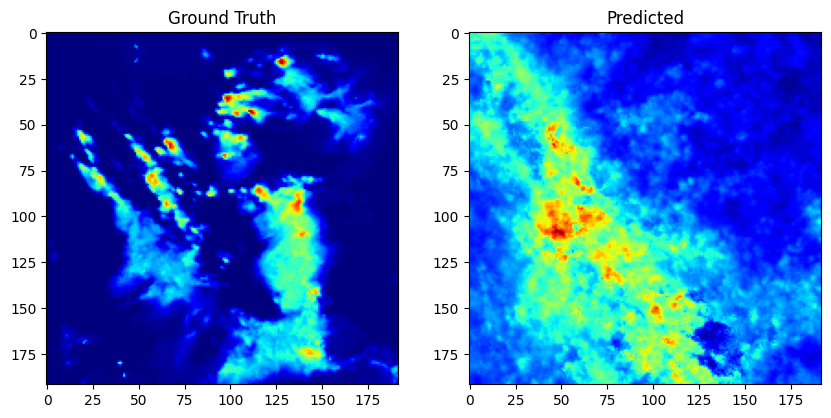

In [62]:
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()
model.half()  # Ensure model is in float16

# Get a sample from the dataset
sample_input, sample_target = dataset[0]
sample_input = sample_input.unsqueeze(0).to("cuda").half()  # Convert input to float16

# Predict
with torch.no_grad():
    predicted_output = model(sample_input).cpu().numpy().squeeze()

# Plot the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_target.numpy(), cmap="jet")
plt.title("Ground Truth")

plt.subplot(1, 2, 2)
plt.imshow(predicted_output, cmap="jet")
plt.title("Predicted")

plt.show()


In [ ]:
import os
import numpy as np
import h5py
import cv2
import torch
import matplotlib.pyplot as plt
import PIL
import IPython.display

def load_event(event_id, h5_file="data/train.h5"):
    """Loads one event's data from train.h5 given an event ID."""
    with h5py.File(h5_file, "r") as f:
        group = f[event_id]
        return {
            "vis": group["vis"][:],
            "ir069": group["ir069"][:],
            "ir107": group["ir107"][:],
            "vil": group["vil"][:],
            "lght": group["lght"][:],
        }

def make_gif(outfile, files, fps=10, loop=0):
    """Combines a list of saved PNG files into a GIF."""
    imgs = [PIL.Image.open(file) for file in files]
    imgs[0].save(
        fp=outfile,
        format='gif',
        append_images=imgs[1:],
        save_all=True,
        duration=int(1000/fps),
        loop=loop
    )
    im = IPython.display.Image(filename=outfile)
    im.reload()
    return im

def plot_event_prediction(event_id, model, output_gif=True, save_gif=True):
    """
    Loads an event, loops over 36 frames, plots VIS, IR, VIL (GT), plus predicted VIL.
    Resizes IR to 384×384 if needed to match VIS shape.
    """
    event = load_event(event_id)
    t = event["lght"][:, 0]  # time-of-lightning array in seconds (relative to first frame)

    model.eval()

    # We'll store frame images here if output_gif=True
    frame_files = []

    def prepare_input_for_model(vis_img, ir069_img, ir107_img):
        # Force everything to (384,384)
        H, W = vis_img.shape
        if (ir069_img.shape[0] != H) or (ir069_img.shape[1] != W):
            ir069_img = cv2.resize(ir069_img, (W, H), interpolation=cv2.INTER_AREA)
        if (ir107_img.shape[0] != H) or (ir107_img.shape[1] != W):
            ir107_img = cv2.resize(ir107_img, (W, H), interpolation=cv2.INTER_AREA)

        # Stack 9-channel input
        input_data = np.stack([
            vis_img, vis_img, vis_img,
            ir069_img, ir069_img, ir069_img,
            ir107_img, ir107_img, ir107_img
        ], axis=-1)  # shape => (384,384,9) if VIS is 384×384

        # Convert to (batch=1, channels=9, H=384, W=384)
        input_tensor = torch.tensor(input_data, dtype=torch.float16).permute(2,0,1).unsqueeze(0).to("cuda")
        return input_tensor

    def plot_one_frame(frame_idx):
        f = (t >= frame_idx*5*60 - 2.5*60) & (t < frame_idx*5*60 + 2.5*60)

        vis_frame   = event["vis"][:,:,frame_idx]
        ir069_frame = event["ir069"][:,:,frame_idx]
        ir107_frame = event["ir107"][:,:,frame_idx]
        vil_frame   = event["vil"][:,:,frame_idx]

        input_tensor = prepare_input_for_model(vis_frame, ir069_frame, ir107_frame)

        with torch.no_grad():
            x = torch.relu(model.bn1(model.conv1(input_tensor)))
            x = torch.relu(model.bn2(model.conv2(x)))
            x = model.pool(x)
            predicted_output = x.cpu().numpy().squeeze()

            # If shape=(C,H,W), pick first channel
            if predicted_output.ndim == 3:
                predicted_output = predicted_output[0]

            # Normalize predicted output to [0, 1]
            mn, mx = predicted_output.min(), predicted_output.max()
            if mx > mn:
                predicted_output = (predicted_output - mn) / (mx - mn)
            else:
                predicted_output = np.zeros_like(predicted_output)

        fig, axs = plt.subplots(1,5, figsize=(20,4))
        fig.suptitle(f"Event: {event_id}, Frame: {frame_idx}, Time: {frame_idx*5} min")

        axs[0].imshow(vis_frame, vmin=0, vmax=10000, cmap="gray")
        axs[0].set_title("Visible")

        axs[1].imshow(ir069_frame, vmin=-8000, vmax=-1000, cmap="viridis")
        axs[1].set_title("IR (Water Vapor)")

        axs[2].imshow(ir107_frame, vmin=-7000, vmax=2000, cmap="inferno")
        axs[2].set_title("IR (Cloud Temp)")

        axs[3].imshow(vil_frame, vmin=0, vmax=255, cmap="turbo")
        axs[3].set_title("Radar (Ground Truth)")

        # Use the same vmin and vmax for predicted output as ground truth
        axs[4].imshow(predicted_output, cmap="turbo", vmin=0, vmax=1)
        axs[4].set_title("Radar (Predicted)")

        if output_gif:
            png_file = f"_temp_{event_id}_{frame_idx}.png"
            fig.savefig(png_file, bbox_inches="tight", dpi=150, pad_inches=0.02, facecolor="white")
            plt.close(fig)
            return png_file
        else:
            plt.show()
            return None

    if output_gif:
        for ti in range(36):
            file = plot_one_frame(ti)
            frame_files.append(file)

        gif_file = f"{event_id}_prediction.gif"
        im = make_gif(gif_file, frame_files, fps=10, loop=0)

        for file in frame_files:
            os.remove(file)

        IPython.display.display(im)
        if not save_gif:
            os.remove(gif_file)
    else:
        # Show just a few frames
        plot_one_frame(0)
        plot_one_frame(17)
        plot_one_frame(34)

# Usage:
model.to("cuda")
plot_event_prediction("S778114", model, output_gif=True, save_gif=True)
print("Any NaNs?:", np.isnan(predicted_output).any())
